## 🔮 Predict whether a customer will cancel their hotel booking

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/sample_submission.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/train.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/test.csv


## 📂 Import necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


from pathlib import Path


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42


## 💾 Load data and overview

In [3]:
DATA_DIR = Path('/kaggle/input/mlp-term-3-2025-kaggle-assignment-2')
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
SAMPLE_SUB_PATH = DATA_DIR / 'sample_submission.csv'
OUTPUT_PATH = Path('/kaggle/working/submission.csv')

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)


print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('\nTrain columns:\n', train.dtypes)


Train shape: (29500, 14)
Test shape: (7000, 13)

Train columns:
 id                  int64
adults              int64
children            int64
weekends            int64
weekdays            int64
meal_type          object
room_type          object
arrival            object
lead_time         float64
segment            object
repeat              int64
price             float64
requests            int64
booking_status      int64
dtype: object


## 1) Identify data types of different columns

In [4]:
train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29500 entries, 0 to 29499
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29500 non-null  int64  
 1   adults          29500 non-null  int64  
 2   children        29500 non-null  int64  
 3   weekends        29500 non-null  int64  
 4   weekdays        29500 non-null  int64  
 5   meal_type       29500 non-null  object 
 6   room_type       28659 non-null  object 
 7   arrival         29500 non-null  object 
 8   lead_time       27805 non-null  float64
 9   segment         29500 non-null  object 
 10  repeat          29500 non-null  int64  
 11  price           27917 non-null  float64
 12  requests        29500 non-null  int64  
 13  booking_status  29500 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 3.2+ MB


,id,adults,children,weekends,weekdays,meal_type,room_type,arrival,lead_time,segment,repeat,price,requests,booking_status
0,0,2,0,0,1,Not Selected,Room_Type 1,2018-05-21,54.0,Online,0,116.10,0,1
1,1,1,0,3,6,Not Selected,Room_Type 1,2018-11-12,12.0,Online,0,71.87,1,1
2,2,2,0,0,2,Meal Plan 1,Room_Type 2,2018-01-06,34.0,Online,0,71.55,1,0
3,3,1,0,2,1,Meal Plan 1,Room_Type 1,2018-02-14,4.0,Corporate,1,66.00,0,0
4,4,2,0,2,3,Meal Plan 1,Room_Type 1,2018-07-08,155.0,Offline,0,72.25,0,0


### Data types

In [5]:
# Quick data types grouping
dtype_summary = pd.DataFrame({'column': train.columns, 'dtype': train.dtypes.astype(str)})
print(dtype_summary)


# Convert possible date column(s)
if 'arrival' in train.columns:
    train['arrival'] = pd.to_datetime(train['arrival'], errors='coerce')
    test['arrival'] = pd.to_datetime(test['arrival'], errors='coerce')
    print('\nConverted `arrival` to datetime.')



                        column    dtype
id                          id    int64
adults                  adults    int64
children              children    int64
weekends              weekends    int64
weekdays              weekdays    int64
meal_type            meal_type   object
room_type            room_type   object
arrival                arrival   object
lead_time            lead_time  float64
segment                segment   object
repeat                  repeat    int64
price                    price  float64
requests              requests    int64
booking_status  booking_status    int64

Converted `arrival` to datetime.


### 2) Descriptive statistics of Numerical Columns

In [6]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
print('Numerical columns:', num_cols)


display(train[num_cols].describe().T)


# If `id` exists, treat as index
if 'id' in train.columns:
    train.set_index('id', inplace=True)
if 'id' in test.columns:
    test.set_index('id', inplace=True)

Numerical columns: ['id', 'adults', 'children', 'weekends', 'weekdays', 'lead_time', 'repeat', 'price', 'requests', 'booking_status']


,count,mean,std,min,25%,50%,75%,max
id,29500.0,14749.500000,8516.060807,0.0,7374.75,14749.50,22124.25,29499.0
adults,29500.0,1.843559,0.518711,0.0,2.00,2.00,2.00,4.0
children,29500.0,0.106576,0.405517,0.0,0.00,0.00,0.00,10.0
weekends,29500.0,0.808136,0.868835,0.0,0.00,1.00,2.00,6.0
weekdays,29500.0,2.202237,1.404200,0.0,1.00,2.00,3.00,17.0
lead_time,27805.0,85.405431,85.939750,0.0,17.00,58.00,127.00,443.0
repeat,29500.0,0.026000,0.159138,0.0,0.00,0.00,0.00,1.0
price,27917.0,103.483304,35.120922,0.0,80.50,99.88,120.18,375.5
requests,29500.0,0.619661,0.785919,0.0,0.00,0.00,1.00,5.0
booking_status,29500.0,0.326441,0.468919,0.0,0.00,0.00,1.00,1.0


### 3) Handling Missing values and 4) Duplicates

In [7]:
# Missing values overview
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_test = test.isnull().sum().sort_values(ascending=False)
print('\nMissing values in train:\n', missing_train[missing_train>0])
print('\nMissing values in test:\n', missing_test[missing_test>0])

# Duplicates
dups = train.duplicated().sum()
print('\nDuplicate rows in train:', dups)


Missing values in train:
 lead_time    1695
price        1583
room_type     841
arrival        29
dtype: int64

Missing values in test:
 room_type    1660
lead_time     412
price         406
arrival         8
dtype: int64

Duplicate rows in train: 6958


### 5) Outlier Detection + Scatter Plot

Price outlier thresholds: 20.97999999999999 179.70000000000002
Lead time outlier thresholds: -148.0 292.0

Price outliers count: 1336
Lead time outliers count: 905


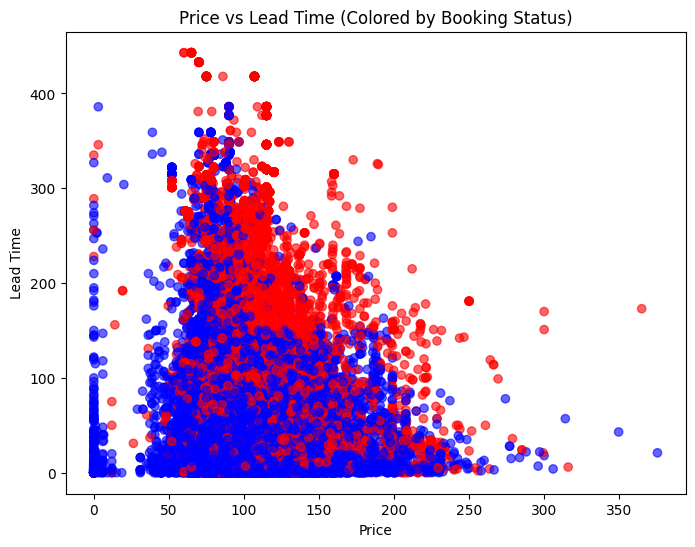

In [8]:
#OUTLIER DETECTION (IQR method)

def detect_outliers_iqr(series):    
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

price_lower, price_upper = detect_outliers_iqr(train['price'])
lead_lower, lead_upper = detect_outliers_iqr(train['lead_time'])

print("Price outlier thresholds:", price_lower, price_upper)
print("Lead time outlier thresholds:", lead_lower, lead_upper)

train['price_outlier'] = (train['price'] < price_lower) | (train['price'] > price_upper)
train['lead_time_outlier'] = (train['lead_time'] < lead_lower) | (train['lead_time'] > lead_upper)

print("\nPrice outliers count:", train['price_outlier'].sum())
print("Lead time outliers count:", train['lead_time_outlier'].sum())

#----------------------------
# SCATTER: PRICE vs LEAD_TIME colored by booking_status
#----------------------------

plt.figure(figsize=(8,6))

#booking_status 0 and 1 colored differently (allowed because user requested)

colors = {0: "blue", 1: "red"}

plt.scatter(
train['price'],
train['lead_time'],
c=train['booking_status'].map(colors),
alpha=0.6
)

plt.title("Price vs Lead Time (Colored by Booking Status)")
plt.xlabel("Price")
plt.ylabel("Lead Time")
plt.show()

## 🎯 Final Combined Interpretation

* Price outliers exist, but price does not meaningfully separate cancelled vs non-cancelled bookings.Slightly higher price → slightly higher cancellation, but the impact is weak.

* Lead time outliers are highly predictive.Very long lead times (200–450 days) correspond to extremely high cancellation rates.

* Scatter plot confirms that cancellation clusters are driven by lead_time, not price.
Price shows no clean clusters or boundaries.

### 6) Target distribution, Price distribution & Correlation heatmap for numerical features

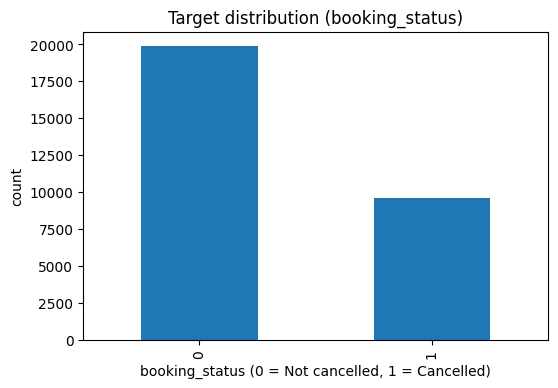

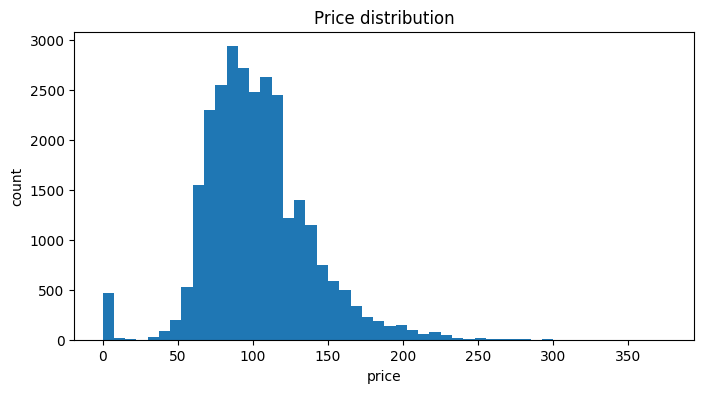

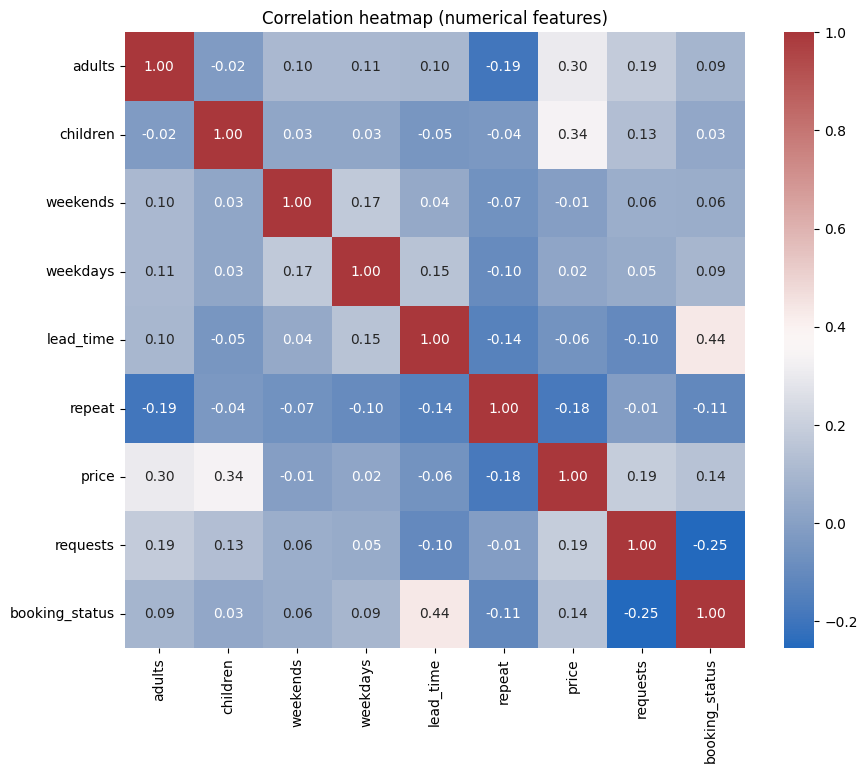

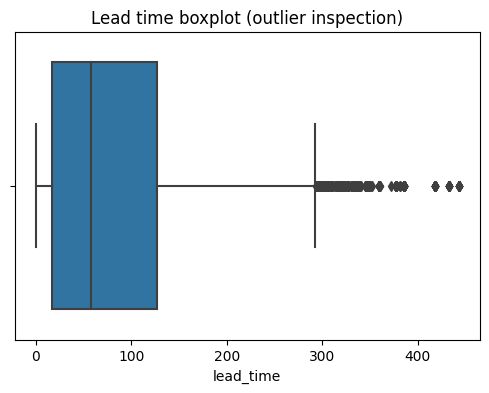

In [9]:
# 1) Target distribution
if 'booking_status' in train.columns:
    plt.figure(figsize=(6,4))
    train['booking_status'].value_counts().plot(kind='bar')
    plt.title('Target distribution (booking_status)')
    plt.xlabel('booking_status (0 = Not cancelled, 1 = Cancelled)')
    plt.ylabel('count')
    plt.show()


# 2) Price distribution
if 'price' in train.columns:
    plt.figure(figsize=(8,4))
    plt.hist(train['price'].dropna(), bins=50)
    plt.title('Price distribution')
    plt.xlabel('price')
    plt.ylabel('count')
    plt.show()


# 3) Correlation heatmap for numerical features
plt.figure(figsize=(10,8))
corr = train.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag')
plt.title('Correlation heatmap (numerical features)')
plt.show()


# 4) Boxplot to inspect outliers for a numeric column (e.g., lead_time)
if 'lead_time' in train.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=train['lead_time'].dropna())
    plt.title('Lead time boxplot (outlier inspection)')
    plt.show()

## 🔥 Ultimate takeaway:
📌 Lead time is a high-impact feature.

📌 Price is a low-impact feature unless combined with other variables (room_type, segment).

### 7) Feature engineering and preprocessing

In [10]:
# Identify feature lists
TARGET = 'booking_status' if 'booking_status' in train.columns else 'target'
all_features = train.columns.drop(TARGET)


# Heuristic separation
numeric_features = train.select_dtypes(include=[np.number]).columns.drop(TARGET, errors='ignore').tolist()
cat_features = train.select_dtypes(include=['object', 'category']).columns.tolist()
# treat datetime as numeric features after extracting useful parts
if 'arrival' in train.columns:
    for df in (train, test):
        df['arrival_month'] = df['arrival'].dt.month
        df['arrival_day'] = df['arrival'].dt.day
    numeric_features += ['arrival_month', 'arrival_day']


# Remove id if present
numeric_features = [c for c in numeric_features if c != 'id']

print('Numeric features:', numeric_features)
print('Categorical features:', cat_features)


# Imputation and encoding pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='drop'
)


# Note on outliers: For tree-based models we don't need to remove outliers necessarily. For linear models / KNN we scaled numeric features.


Numeric features: ['adults', 'children', 'weekends', 'weekdays', 'lead_time', 'repeat', 'price', 'requests', 'arrival_month', 'arrival_day']
Categorical features: ['meal_type', 'room_type', 'segment']


### Train/validation split

In [11]:
X = train.drop(columns=[TARGET])
y = train[TARGET]


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, stratify=y, random_state=RANDOM_STATE)
print('Train/val shapes:', X_train.shape, X_val.shape)


Train/val shapes: (28025, 16) (1475, 16)


### 8) Model building — train at least 7 different model types

In [12]:

# We'll build a simple pipeline for each model and evaluate using ROC AUC and accuracy on validation set.


models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    'KNeighbors': KNeighborsClassifier(),
    'SVC': SVC(probability=True, random_state=RANDOM_STATE),
    
    # Models that handle categorical features natively
    'CatBoost': CatBoostClassifier(
        iterations=100,
        random_state=RANDOM_STATE,
        verbose=0,  # Suppress training output
        allow_writing_files=False  # Prevent creating temp files
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        verbose=-1  # Suppress warnings
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        enable_categorical=True,  # Enable native categorical support
        eval_metric='logloss'
    )
}

results = []
for name, clf in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, y_proba)
    acc = accuracy_score(y_val, y_pred)
    results.append({'model': name, 'auc': auc, 'accuracy': acc})
    print(f'{name}: AUC={auc:.4f}, ACC={acc:.4f}')


results_df = pd.DataFrame(results).sort_values('auc', ascending=False)
print('\nModel comparison:\n', results_df)


LogisticRegression: AUC=0.8614, ACC=0.7986
DecisionTree: AUC=0.8298, ACC=0.8468
RandomForest: AUC=0.9490, ACC=0.8956
ExtraTrees: AUC=0.9436, ACC=0.8942
HistGradientBoosting: AUC=0.9391, ACC=0.8698
AdaBoost: AUC=0.8806, ACC=0.8088
KNeighbors: AUC=0.9001, ACC=0.8495
SVC: AUC=0.8962, ACC=0.8420
CatBoost: AUC=0.9357, ACC=0.8692
LightGBM: AUC=0.9420, ACC=0.8719
XGBoost: AUC=0.9429, ACC=0.8712

Model comparison:
                    model       auc  accuracy
2           RandomForest  0.948994  0.895593
3             ExtraTrees  0.943585  0.894237
10               XGBoost  0.942917  0.871186
9               LightGBM  0.941998  0.871864
4   HistGradientBoosting  0.939146  0.869831
8               CatBoost  0.935666  0.869153
6             KNeighbors  0.900096  0.849492
7                    SVC  0.896245  0.842034
5               AdaBoost  0.880595  0.808814
0     LogisticRegression  0.861449  0.798644
1           DecisionTree  0.829827  0.846780


### 9) Hyperparameter tuning on any 3 models

In [13]:
# We'll tune RandomForest, HistGradientBoosting, and XGB using RandomizedSearchCV (a small search for speed).


# 1) RandomForest
rf = Pipeline(steps=[('preprocessor', preprocessor), ('clf', RandomForestClassifier(random_state=RANDOM_STATE))])
rf_param = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
}
rf_search = RandomizedSearchCV(rf, rf_param, n_iter=6, scoring='roc_auc', cv=3, random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
print('RF best params:', rf_search.best_params_)


# 2) HistGradientBoosting
hgb_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', HistGradientBoostingClassifier(random_state=RANDOM_STATE))])
hgb_param = {
    'clf__learning_rate': [0.01, 0.1, 0.2],
    'clf__max_iter': [100, 200],
    'clf__max_depth': [None, 8, 15]
}
hgb_search = RandomizedSearchCV(hgb_pipe, hgb_param, n_iter=6, scoring='roc_auc', cv=3, random_state=RANDOM_STATE, n_jobs=-1)
hgb_search.fit(X_train, y_train)
print('HGB best params:', hgb_search.best_params_)

#3) XGBoost
xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))
])

xgb_param = {
    'clf__n_estimators': [100, 200, 300, 500],        # Number of trees
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],     # Step size shrinkage (eta)
    'clf__max_depth': [3, 5, 7, 10],                  # Maximum depth of a tree
    'clf__subsample': [0.6, 0.8, 1.0],                # Fraction of samples used per tree
    'clf__colsample_bytree': [0.6, 0.8, 1.0]          # Fraction of features used per tree
}

# Increased n_iter to 15 because XGBoost has a larger search space than SVC
xgb_search = RandomizedSearchCV(
    xgb_pipe, 
    xgb_param, 
    n_iter=15, 
    scoring='roc_auc', 
    cv=3, 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
print('XGBoost best params:', xgb_search.best_params_)

RF best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__max_depth': 20}
HGB best params: {'clf__max_iter': 200, 'clf__max_depth': None, 'clf__learning_rate': 0.2}
XGBoost best params: {'clf__subsample': 1.0, 'clf__n_estimators': 300, 'clf__max_depth': 10, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.8}


### 10) Model performance comparison


In [14]:
# We'll compute AUC, accuracy and show classification report for the best tuned model


best_models = {
    'RF_tuned': rf_search.best_estimator_,
    'HGB_tuned': hgb_search.best_estimator_,
    'XGB_tuned': xgb_search.best_estimator_
}


tuned_results = []
for name, pipe in best_models.items():
    y_proba = pipe.predict_proba(X_val)[:,1]
    y_pred = pipe.predict(X_val)
    auc = roc_auc_score(y_val, y_proba)
    acc = accuracy_score(y_val, y_pred)
    tuned_results.append({'model': name, 'auc': auc, 'accuracy': acc})
    print(name)
    print('AUC:', auc)
    print('Accuracy:', acc)
    print(classification_report(y_val, y_pred))


pd.DataFrame(tuned_results).sort_values('auc', ascending=False)

RF_tuned
AUC: 0.9491041885408081
Accuracy: 0.8915254237288136
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       994
           1       0.85      0.81      0.83       481

    accuracy                           0.89      1475
   macro avg       0.88      0.87      0.88      1475
weighted avg       0.89      0.89      0.89      1475

HGB_tuned
AUC: 0.938382896129375
Accuracy: 0.8725423728813559
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       994
           1       0.82      0.78      0.80       481

    accuracy                           0.87      1475
   macro avg       0.86      0.85      0.85      1475
weighted avg       0.87      0.87      0.87      1475

XGB_tuned
AUC: 0.9474916024211798
Accuracy: 0.8861016949152543
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       994
           1       0.83      0.82      0.82       

,model,auc,accuracy
0,RF_tuned,0.949104,0.891525
2,XGB_tuned,0.947492,0.886102
1,HGB_tuned,0.938383,0.872542


### Evaluate tuned models on validation set

In [15]:
# Combine initial and tuned results
comparison_df = pd.concat([results_df, pd.DataFrame(tuned_results)], sort=False).reset_index(drop=True)
print(comparison_df.sort_values('accuracy', ascending=False))


# Cross-validated AUC for top model
top_model_name = comparison_df.sort_values('accuracy', ascending=False).iloc[0]['model']
print('Top model (from list) by ACC:', top_model_name)


# For final model we will use the best tuned model among tuned ones (if tuned versions are better)
final_model = None
all_tuned = pd.DataFrame(tuned_results)
if not all_tuned.empty:
    best_tuned_name = all_tuned.sort_values('accuracy', ascending=False).iloc[0]['model']
    final_model = best_models[best_tuned_name]
    print('Selected final model:', best_tuned_name)
else:
    # fallback to best from initial models
    best_init = results_df.sort_values('accuracy', ascending=False).iloc[0]['model']
    final_model = Pipeline(steps=[('preprocessor', preprocessor), ('clf', models[best_init])])
    final_model.fit(X_train, y_train)
    print('Selected final model (init):', best_init)

                   model       auc  accuracy
0           RandomForest  0.948994  0.895593
1             ExtraTrees  0.943585  0.894237
11              RF_tuned  0.949104  0.891525
13             XGB_tuned  0.947492  0.886102
12             HGB_tuned  0.938383  0.872542
3               LightGBM  0.941998  0.871864
2                XGBoost  0.942917  0.871186
4   HistGradientBoosting  0.939146  0.869831
5               CatBoost  0.935666  0.869153
6             KNeighbors  0.900096  0.849492
10          DecisionTree  0.829827  0.846780
7                    SVC  0.896245  0.842034
8               AdaBoost  0.880595  0.808814
9     LogisticRegression  0.861449  0.798644
Top model (from list) by ACC: RandomForest
Selected final model: RF_tuned


### 10) Train final model on full training data and create submission

In [16]:
final_model.fit(X, y)

# 'id' and 'booking_status' where booking_status is 0/1 (integer).
# Prefer an explicit `id` column if present, otherwise use the DataFrame index.
if 'id' in test.columns:
    test_ids = test['id'].astype(int).reset_index(drop=True)
else:
    # if index is meaningful (we may have set id as index earlier), use the index
    test_ids = pd.Series(test.index).astype(int).reset_index(drop=True)


# Predict class labels (0 or 1) for the test set
pred_labels = final_model.predict(test)
# Ensure alignment length matches
if len(pred_labels) != len(test_ids):
    raise ValueError(f"Mismatch between predictions ({len(pred_labels)}) and test ids ({len(test_ids)})")

submission = pd.DataFrame({'id': test_ids, 'booking_status': pred_labels.astype(int)})

submission.to_csv(OUTPUT_PATH, index=False)
print('Wrote submission to', OUTPUT_PATH)

Wrote submission to /kaggle/working/submission.csv
